In [1]:
!pip install networkx numpy scikit-learn

In [2]:
import numpy as np
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity
import random

Multi-Attributed Network Dataset

In [3]:
# Create graph
G = nx.karate_club_graph()

# Add random attributes to nodes
for node in G.nodes():
    G.nodes[node]['attr'] = np.random.rand(5)   # 5 attributes per node

Continuous Encoding

In [4]:
def continuous_encoding(G):

    encoding = {}

    for node in G.nodes():
        neighbors = list(G.neighbors(node))

        if len(neighbors) == 0:
            encoding[node] = None
        else:
            probs = np.random.rand(len(neighbors))
            probs = probs / probs.sum()

            encoding[node] = (neighbors, probs)

    return encoding

Double Decoding

In [5]:
def double_decoding(G, encoding):

    communities = {}
    overlapping_nodes = []

    for node in G.nodes():

        if encoding[node] is None:
            continue

        neighbors, probs = encoding[node]

        first = neighbors[np.argmax(probs)]

        probs_copy = probs.copy()
        probs_copy[np.argmax(probs)] = -1
        second = neighbors[np.argmax(probs_copy)]

        communities.setdefault(first, []).append(node)
        communities.setdefault(second, []).append(node)

        if first != second:
            overlapping_nodes.append(node)

    return communities, overlapping_nodes

Objective 1 — Network Structure

In [6]:
def modularity_score(G, communities):

    comm_list = list(communities.values())

    return nx.algorithms.community.quality.modularity(G, comm_list)

Objective 2 — Attribute Similarity

In [7]:
def attribute_similarity(G, communities):

    score = 0
    count = 0

    for nodes in communities.values():

        attrs = [G.nodes[n]['attr'] for n in nodes]

        if len(attrs) > 1:
            sim = cosine_similarity(attrs)
            score += sim.mean()
            count += 1

    if count == 0:
        return 0

    return score / count

Evolutionary Optimization (Simplified MOEA)

In [8]:
def evolutionary_community_detection(G, iterations=50):

    best_solution = None
    best_score = -1

    for i in range(iterations):

        encoding = continuous_encoding(G)

        communities, overlapping = double_decoding(G, encoding)

        try:
            mod = modularity_score(G, communities)
        except:
            mod = 0

        attr = attribute_similarity(G, communities)

        score = mod + attr

        if score > best_score:
            best_score = score
            best_solution = (communities, overlapping)

    return best_solution

Run the Algorithm

In [9]:
communities, overlapping_nodes = evolutionary_community_detection(G)

print("Detected Communities:")
for k,v in communities.items():
    print(k,":",v)

print("\nOverlapping Nodes:")
print(overlapping_nodes)

Detected Communities:
2 : [0, 9, 27]
4 : [0, 6]
13 : [1, 3, 33]
7 : [1]
28 : [2, 31]
32 : [2, 14, 15, 18, 20, 22, 29, 30]
0 : [3, 4, 7, 8, 10, 11, 11, 12, 17, 19, 21, 31]
10 : [4, 5]
6 : [5, 16]
16 : [6]
3 : [7, 12]
30 : [8]
33 : [9, 13, 14, 15, 18, 20, 22, 23, 26, 28, 30]
5 : [10, 16]
1 : [13, 17, 19, 21]
25 : [23, 24]
31 : [24, 28, 32, 33]
24 : [25, 27]
23 : [25]
29 : [26]
26 : [29]
15 : [32]

Overlapping Nodes:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]


Graph

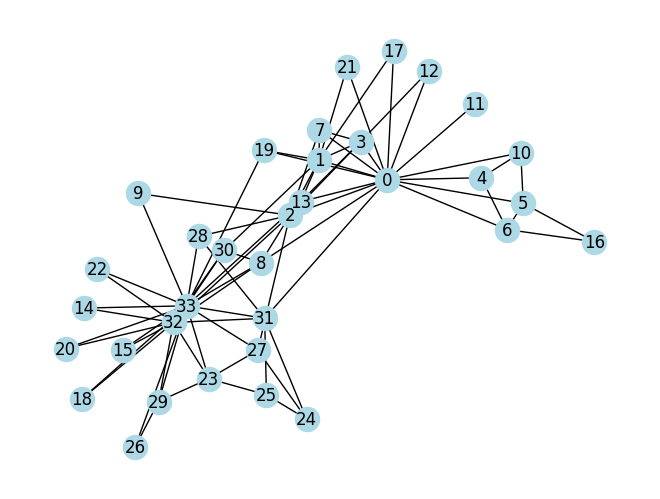

In [10]:
import matplotlib.pyplot as plt

pos = nx.spring_layout(G)

nx.draw(G, pos, node_color='lightblue', with_labels=True)
plt.show()